### Importy

In [2]:
import torch
import onnxruntime as ort
import cv2
import numpy as np
import os
import pickle
from insightface.app import FaceAnalysis
from pathlib import Path

### Sprawdzanie GPU

In [2]:
cuda_available = torch.cuda.is_available()
print(f"PyTorch CUDA: {cuda_available}")
if cuda_available:
    print(f"Urządzenie: {torch.cuda.get_device_name(0)}")
    print(f"Liczba GPU: {torch.cuda.device_count()}")

PyTorch CUDA: False


In [3]:
providers = ort.get_available_providers()
print(f"Dostępne procesory ONNX: {providers}")

if 'CUDAExecutionProvider' in providers:
    print("InsightFace będzie korzystać z GPU (CUDA).")
else:
    print("Brak CUDAExecutionProvider (CPU).")


Dostępne procesory ONNX: ['AzureExecutionProvider', 'CPUExecutionProvider']
Brak CUDAExecutionProvider (CPU).


### Inicjalizacja modelu

In [3]:
app = FaceAnalysis(name='buffalo_l', providers=['CUDAExecutionProvider', 'CPUExecutionProvider'])
app.prepare(ctx_id=0, det_size=(640, 640))

f:\Studia_pwr\semestr3\biometria\projekt1\projekt_biometria\facial-recognition-system\.venv\Lib\site-packages\onnxruntime\capi\onnxruntime_inference_collection.py:123: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\ALA/.insightface\models\buffalo_l\1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\ALA/.insightface\models\buffalo_l\2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\ALA/.insightface\models\buffalo_l\det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\ALA/.insightface\models\buffalo_l\genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\ALA/.insightface\models\buffalo_l\w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
se

### Funkcja do detekcji, alignmentu i ekstrakcji cech

In [4]:
def get_face_embedding(image_path):
    img = cv2.imread(image_path)
    if img is None:
        return None

    faces = app.get(img)
    
    if len(faces) == 0:
        print(f"Undetected face in the image: {image_path}")
        return None

    # Zwracamy embedding pierwszej wykrytej twarzy (zakładamy 1 osobę na foto)
    # faces[0].normed_embedding to wektor 512-wymiarowy
    return faces[0].normed_embedding

In [ ]:
emb1 = get_face_embedding('data/000001.jpg')
emb2 = get_face_embedding('data/000002.jpg')

In [24]:
emb1.shape

(512,)

### Wyliczenie miary podobieństwa (Cosinus similarity)

In [18]:
if emb1 is not None and emb2 is not None:
    similarity = np.dot(emb1, emb2) / (np.linalg.norm(emb1) * np.linalg.norm(emb2))
    print(f"Podobieństwo: {similarity:.4f}")

Podobieństwo: -0.0046


### Sprawdzenie datasetu

In [22]:
from pathlib import Path

gallery_folder = Path(r"data_processed/gallery")
test_known_folder = Path(r"data_processed/test_known")
test_unknown_folder = Path(r"data_processed/test_unknown")

num_files_in_gallery = sum(1 for p in gallery_folder.iterdir() if p.is_file())
num_files_in_test_known = sum(1 for p in test_known_folder.iterdir() if p.is_file())
num_files_in_test_unknown = sum(1 for p in test_unknown_folder.iterdir() if p.is_file())

print("Files in gallery:", num_files_in_gallery)
print("Files in test_unknown:", num_files_in_test_unknown)
print("Files in test_known:", num_files_in_test_known)

Files in gallery: 102
Files in test_unknown: 120
Files in test_known: 1020


### Utworzenie wektorów osadzeń na podstawie zdjęć 102 użytkowników

In [63]:
aaron_eckhart_emb = get_face_embedding('data_processed/test_known/Alicja_9.jpeg')
aaron_eckhart_emb

Undetected face in the image: data_processed/test_known/Alicja_9.jpeg


In [70]:
def create_biometric_database(source_folder, output_file="face_db.pkl"):
    database = {}
        
    print("Processing...")
    
    for file_name in os.listdir(source_folder):
        if not file_name.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue
            
        person_id = os.path.splitext(file_name)[0]
        img_path = os.path.join(source_folder, file_name)
        
        img = cv2.imread(img_path)

        if img is None:
            print(f"Error: Could not read image {file_name}. Skipping.")
            continue

        h, w = img.shape[:2]
        pad_h, pad_w = int(h * 0.4), int(w * 0.4)
        img_padded = cv2.copyMakeBorder(
            img, pad_h, pad_h, pad_w, pad_w, 
            cv2.BORDER_CONSTANT, value=[0, 0, 0]
        )

        faces = app.get(img_padded)
        
        if len(faces) > 0:
            # Sortujemy twarze po wielkości (na wypadek gdyby w tle był ktoś inny)
            # i bierzemy największą (główną) twarz
            faces = sorted(faces, key=lambda x: (x.bbox[2]-x.bbox[0])*(x.bbox[3]-x.bbox[1]), reverse=True)
            
            embedding = faces[0].normed_embedding
            
            database[person_id] = embedding
            print(f"Saved: {person_id}")
        else:
            print(f"Error saving: {person_id}")

    with open(output_file, "wb") as f:
        pickle.dump(database, f)
        
    print(f"\nDone! Embeddings saved in {output_file}")
    return database

In [73]:
create_biometric_database('data_processed/gallery/')

Processing...
Saved: Aaron_Eckhart_ref
Saved: Adrien_Brody_ref
Saved: Alexander_Skarsgard_ref
Saved: Alicja_ref
Saved: America_Ferrera_ref
Saved: Andrea_Bowen_ref
Saved: Angell_Conwell_ref
Saved: Angie_Harmon_ref
Saved: Antonio_Banderas_ref
Saved: Bernie_Mac_ref
Saved: Brendan_Fraser_ref
Saved: Christel_Khalil_ref
Saved: Ciara_Bravo_ref
Saved: Clint_Eastwood_ref
Saved: Colin_Farrell_ref
Saved: Crystal_Bernard_ref
Saved: Daniel_Radcliffe_ref
Saved: Danny_Trejo_ref
Saved: Dan_Lauria_ref
Saved: Dianna_Agron_ref
Saved: Edie_Falco_ref
Saved: Ed_Harris_ref
Saved: Elizabeth_Berkley_ref
Saved: Elizabeth_Hendrickson_ref
Saved: Eliza_Dushku_ref
Saved: Ellen_Greene_ref
Saved: Emile_Hirsch_ref
Saved: Farah_Fath_ref
Saved: Florencia_Lozano_ref
Saved: Gabrielle_Carteris_ref
Saved: Heather_Locklear_ref
Saved: J.K._Simmons_ref
Saved: Jakub_ref
Saved: James_Brolin_ref
Saved: James_Frain_ref
Saved: Jamie_Foxx_ref
Saved: Jamie_Luner_ref
Saved: Jane_Lynch_ref
Saved: Jared_Padalecki_ref
Saved: Jason_Batema

{'Aaron_Eckhart_ref': array([ 4.46673594e-02,  9.97412764e-03,  1.41310627e-02,  4.37175743e-02,
        -1.04909139e-02, -2.05486938e-02, -5.70709594e-02, -5.30050136e-02,
        -4.12916671e-03,  1.12755541e-02,  7.99206831e-03, -1.32724661e-02,
         5.24081476e-02, -5.84124215e-02,  4.18157130e-02, -4.39009280e-04,
        -5.75906634e-02, -3.34601998e-02,  1.51671488e-02, -5.62507734e-02,
         4.17294167e-02, -1.35154435e-02,  5.78899831e-02, -5.27283410e-03,
         2.18846761e-02,  5.17101921e-02, -7.84392282e-03,  4.04822901e-02,
        -1.85999162e-02,  6.28017709e-02, -1.86661165e-02,  4.86015640e-02,
        -3.87004539e-02,  1.12600848e-02,  4.66400757e-03,  3.94917317e-02,
        -9.32850596e-03, -3.88543867e-02, -1.92149654e-02,  3.59252356e-02,
        -1.93418451e-02,  1.09345727e-01, -1.06361052e-02,  2.63858829e-02,
         3.37890498e-02,  2.14494765e-02, -7.29343668e-02, -5.11205159e-02,
         7.79906986e-03, -7.26377368e-02,  4.68526967e-02, -2.57452

### Wczytanie bazy danych

In [5]:
with open("face_db.pkl", "rb") as f:
    db = pickle.load(f)

klucz = list(db.keys())[0]
wektor = db[klucz]

print(f"Osoba: {klucz}")
print(f"Typ danych: {wektor.dtype}")
print(f"Kształt wektora: {wektor.shape}")
print(f"Pierwsze 5 liczb wektora: {wektor[:5]}")

Osoba: Aaron_Eckhart_ref
Typ danych: float32
Kształt wektora: (512,)
Pierwsze 5 liczb wektora: [ 0.04466736  0.00997413  0.01413106  0.04371757 -0.01049091]


# experiments 

In [ ]:
def get_face_embedding_with_padding(image_path):
    img = cv2.imread(image_path)
    if img is None:
        return None

    h, w = img.shape[:2]
    pad_h, pad_w = int(h * 0.4), int(w * 0.4)
    img_padded = cv2.copyMakeBorder(
        img, pad_h, pad_h, pad_w, pad_w, 
        cv2.BORDER_CONSTANT, value=[0, 0, 0]
    )

    faces = app.get(img_padded)
    
    if len(faces) == 0:
        # print(f"Undetected face in the image: {image_path}")
        return None

    faces = sorted(faces, key=lambda x: (x.bbox[2]-x.bbox[0])*(x.bbox[3]-x.bbox[1]), reverse=True)
    return faces[0].normed_embedding

## 1. Próby autentyczne i próby oszustwa
Kluczowe elementy testu:

Próby autentyczne (Genuine): 

System porównuje zdjęcie użytkownika z jego własnym wzorcem zapisanym w bazie. Jeśli wynik podobieństwa jest poniżej progu, generowany jest błąd FRR (False Rejection Rate).

Próby oszustwa (Impostor):

System porównuje zdjęcie użytkownika z losowo wybranym, cudzym wzorcem z bazy (tzw. Zero-effort Impostor attack). Jeśli wynik podobieństwa przekroczy próg, generowany jest błąd FAR (False Acceptance Rate).

Zbalansowanie:

Dla każdego zdjęcia testowego wykonywana jest dokładnie jedna próba "swoja" i jedna próba "obca".

In [ ]:
import os
import random
import numpy as np
from tqdm import tqdm

def verify_user(image_path, claimed_id, db, threshold=0.45):
    """
    simulates the user login process to the system.
    returns: (True/False - decision, score - similarity value)
    """
    if claimed_id not in db:
        return False, 0.0 # no user in database
        
    test_embedding = get_face_embedding_with_padding(image_path)
    if test_embedding is None:
        return False, 0.0 # no face detected in the image
        
    registered_embedding = db[claimed_id]
    
    similarity = np.dot(test_embedding, registered_embedding)
    
    is_accepted = similarity >= threshold
    return is_accepted, similarity

import os
import random
import numpy as np
from tqdm import tqdm

def evaluate_system(test_folder, db, threshold=0.45):
    genuine_scores = []
    impostor_scores = [] 
    
    test_files = [f for f in os.listdir(test_folder) if f.endswith(('.jpg', '.jpeg', '.png'))]
    all_db_ids = list(db.keys())
    
    print(f"Rozpoczynam testy na {len(test_files)} zdjęciach...")
    
    for file_name in tqdm(test_files, desc="Ocena skuteczności"):
        
        db_key_genuine = None
        for key in all_db_ids:
            base_name = key.replace('_ref', '') 
            if file_name.startswith(base_name):
                db_key_genuine = key
                break
                
        if db_key_genuine is None:
            continue
            
        img_path = os.path.join(test_folder, file_name)
        test_emb = get_face_embedding_with_padding(img_path) 
        
        if test_emb is None:
            continue
            
        sim_genuine = np.dot(test_emb, db[db_key_genuine])
        genuine_scores.append(sim_genuine)
            
        impostor_db_key = random.choice([uid for uid in all_db_ids if uid != db_key_genuine])
        sim_impostor = np.dot(test_emb, db[impostor_db_key])
        impostor_scores.append(sim_impostor)

    false_accepts = sum(1 for score in impostor_scores if score >= threshold)
    false_rejects = sum(1 for score in genuine_scores if score < threshold)
    
    far = false_accepts / len(impostor_scores) if impostor_scores else 0
    frr = false_rejects / len(genuine_scores) if genuine_scores else 0
    
    print("\n--- WYNIKI TESTÓW ---")
    print(f"Liczba prób Genuine: {len(genuine_scores)}")
    print(f"Liczba prób Impostor: {len(impostor_scores)}")
    print(f"Próg decyzyjny (Threshold): {threshold}")
    print(f"FAR (False Acceptance Rate): {far:.4f} ({false_accepts} błędnych akceptacji)")
    print(f"FRR (False Rejection Rate): {frr:.4f} ({false_rejects} błędnych odrzuceń)")
    
    return genuine_scores, impostor_scores

gen_scores, imp_scores = evaluate_system('data_processed/test_known', db, threshold=0.45)

I start tests na 1000 zdjęciach...


Ocena skuteczności:   0%|          | 0/1000 [00:00<?, ?it/s]f:\Studia_pwr\semestr3\biometria\projekt1\projekt_biometria\facial-recognition-system\.venv\Lib\site-packages\insightface\utils\face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)
Ocena skuteczności: 100%|██████████| 1000/1000 [15:48<00:00,  1.05it/s]


--- WYNIKI TESTÓW ---
Liczba prób Genuine: 990
Liczba prób Impostor: 990
Próg decyzyjny (Threshold): 0.45
FAR (False Acceptance Rate): 0.0000 (0 błędnych akceptacji)
FRR (False Rejection Rate): 0.1101 (109 błędnych odrzuceń)


# 6. EER & ROC
przeprowadź analizę FAR/FRR względem progu decyzyjnego (threshold) oraz
przedstaw krzywą ROC i uzasadnij wybór progu pracy systemu,

--- ANALIZA PROGU ---
Sugerowany idealny próg (Threshold): 0.1587
Błąd EER (FAR i FRR wynoszą tu ok.): 0.0121 (1.21%)


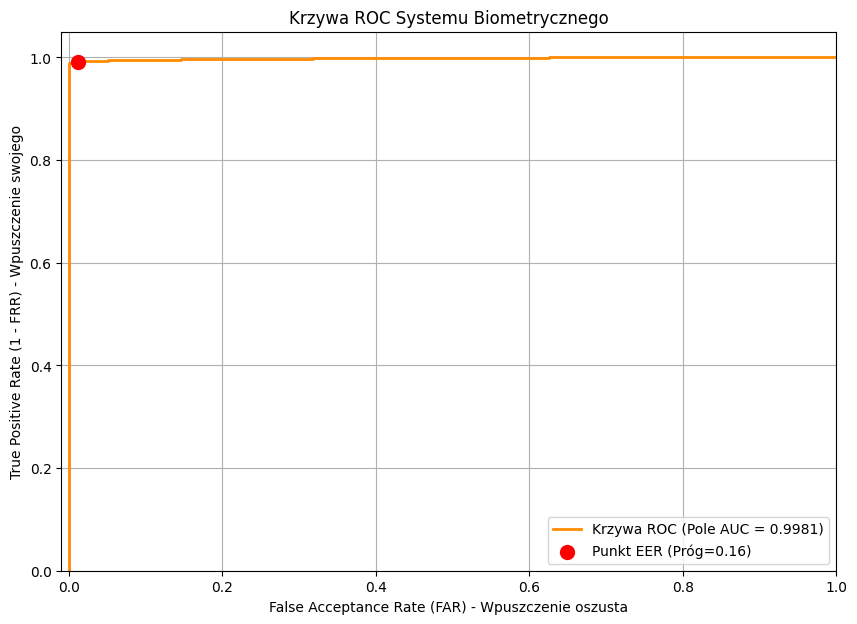

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

y_true = [1] * len(gen_scores) + [0] * len(imp_scores)
y_scores = gen_scores + imp_scores

fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

frr = 1 - tpr

diffs = np.abs(fpr - frr)
eer_index = diffs.argmin()

optimal_threshold = thresholds[eer_index]
eer_value = fpr[eer_index]

print(f"--- ANALIZA PROGU ---")
print(f"Sugerowany idealny próg (Threshold): {optimal_threshold:.4f}")
print(f"Błąd EER (FAR i FRR wynoszą tu ok.): {eer_value:.4f} ({eer_value * 100:.2f}%)")

plt.figure(figsize=(10, 7))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Krzywa ROC (Pole AUC = {roc_auc:.4f})')

plt.scatter(fpr[eer_index], tpr[eer_index], color='red', s=100, zorder=5, 
            label=f'Punkt EER (Próg={optimal_threshold:.2f})')

plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Acceptance Rate (FAR) - Wpuszczenie oszusta')
plt.ylabel('True Positive Rate (1 - FRR) - Wpuszczenie swojego')
plt.title('Krzywa ROC Systemu Biometrycznego')
plt.legend(loc="lower right")
plt.grid(True)

plt.savefig('krzywa_roc_baza1.png')
plt.show()

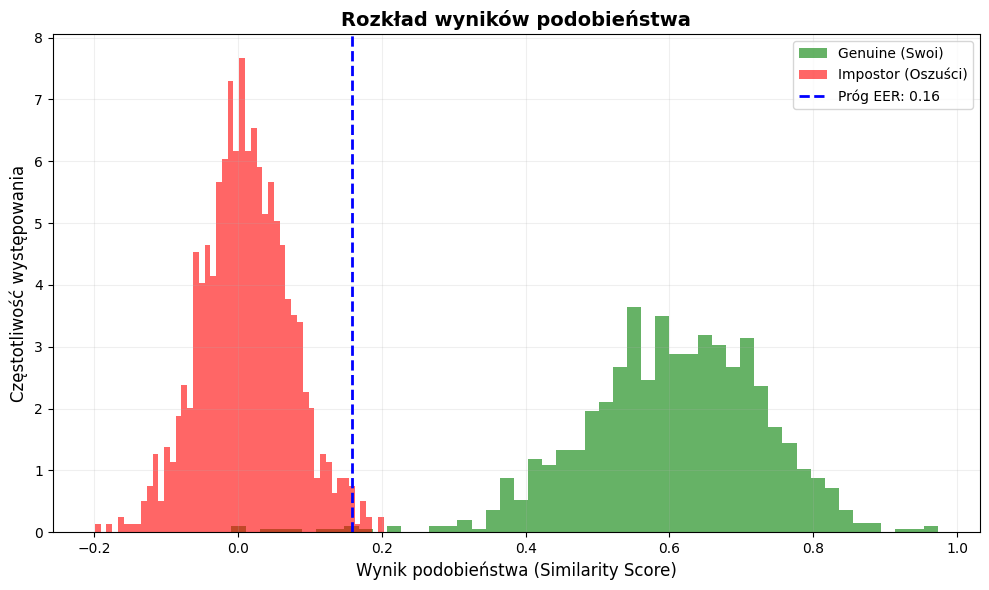

In [36]:
plt.figure(figsize=(10, 6))
plt.hist(gen_scores, bins=50, alpha=0.6, label='Genuine (Swoi)', color='green', density=True)
plt.hist(imp_scores, bins=50, alpha=0.6, label='Impostor (Oszuści)', color='red', density=True)

plt.axvline(optimal_threshold, color='blue', linestyle='--', lw=2, label=f'Próg EER: {optimal_threshold:.2f}')

plt.title('Rozkład wyników podobieństwa', fontsize=14, fontweight='bold')
plt.xlabel('Wynik podobieństwa (Similarity Score)', fontsize=12)
plt.ylabel('Częstotliwość występowania', fontsize=12)
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()


plt.savefig('histogram_rozkładu_wyników.png', dpi=300)
plt.savefig('histogram_rozkładu_wyników.pdf')        

plt.show()

## 2. Analiza wpływu osób niewdrożonych (Unknown Users)
Sprawdzamy, jak system zachowuje się w starciu z osobami, których nie ma w bazie.

In [ ]:
import os
import random
import numpy as np
from tqdm import tqdm

OPTIMAL_THRESHOLD = 0.1587

def test_unknown_users(unknown_folder, db):
    unknown_scores = []
    test_files = [f for f in os.listdir(unknown_folder) if f.endswith(('.jpg', '.jpeg', '.png'))]
    all_db_ids = list(db.keys())
    
    print(f"Testowanie {len(test_files)} zdjęć osób NIEWDROŻONYCH...")
    
    for file_name in tqdm(test_files, desc="Próby włamania (Obcy)"):
        img_path = os.path.join(unknown_folder, file_name)
        test_emb = get_face_embedding_with_padding(img_path)
        
        if test_emb is None:
            continue
            
        #stranger tries to log in as a random account in your system
        claimed_id = random.choice(all_db_ids)
        
        sim_score = np.dot(test_emb, db[claimed_id])
        unknown_scores.append(sim_score)
        
    return unknown_scores


unknown_scores = test_unknown_users('data_processed/test_unknown', db)

# connecting old impostor scores with new unknown scores
combined_impostor_scores = imp_scores + unknown_scores

old_false_accepts = sum(1 for score in imp_scores if score >= OPTIMAL_THRESHOLD)
old_fpr = old_false_accepts / len(imp_scores) if len(imp_scores) > 0 else 0

new_false_accepts = sum(1 for score in combined_impostor_scores if score >= OPTIMAL_THRESHOLD)
new_fpr = new_false_accepts / len(combined_impostor_scores) if len(combined_impostor_scores) > 0 else 0

print("\n--- PORÓWNANIE FPR (Wpływ osób niewdrożonych) ---")
print(f"Próg decyzyjny: {OPTIMAL_THRESHOLD}")
print(f"Liczba prób Impostor (tylko znani): {len(imp_scores)}")
print(f"Liczba prób Impostor (znani + obcy): {len(combined_impostor_scores)}")
print("-" * 40)
print(f"Stary FPR (FAR): {old_fpr:.4f} ({old_fpr * 100:.2f}%) - {old_false_accepts} błędów")
print(f"Nowy FPR (FAR):  {new_fpr:.4f} ({new_fpr * 100:.2f}%) - {new_false_accepts} błędów")

if new_fpr > old_fpr:
    print("\nWNIOSEK: Dodanie osób niewdrożonych ZWIĘKSZYŁO współczynnik FPR.")
elif new_fpr < old_fpr:
    print("\nWNIOSEK: Dodanie osób niewdrożonych ZMNIEJSZYŁO współczynnik FPR (wartość względną).")
else:
    print("\nWNIOSEK: Dodanie osób niewdrożonych NIE WPŁYNĘŁO na współczynnik FPR.")

Testowanie 120 zdjęć osób NIEWDROŻONYCH...


Próby włamania (Obcy):   0%|          | 0/120 [00:00<?, ?it/s]f:\Studia_pwr\semestr3\biometria\projekt1\projekt_biometria\facial-recognition-system\.venv\Lib\site-packages\insightface\utils\face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)
Próby włamania (Obcy): 100%|██████████| 120/120 [02:16<00:00,  1.14s/it]


--- PORÓWNANIE FPR (Wpływ osób niewdrożonych) ---
Próg decyzyjny: 0.1587
Liczba prób Impostor (tylko znani): 990
Liczba prób Impostor (znani + obcy): 1110
----------------------------------------
Stary FPR (FAR): 0.0111 (1.11%) - 11 błędów
Nowy FPR (FAR):  0.0099 (0.99%) - 11 błędów

WNIOSEK: Dodanie osób niewdrożonych ZMNIEJSZYŁO współczynnik FPR (wartość względną).


## 3. Badanie odporności na szum (PSNR)
Symulujemy degradację obrazu spowodowaną. Badamy system dla różnych poziomów Peak Signal-to-Noise Ratio (PSNR).

In [ ]:
import os
import cv2
import random
import numpy as np
from tqdm import tqdm

OPTIMAL_THRESHOLD = 0.1587

def get_embedding_from_image(img):
    if img is None:
        return None
    h, w = img.shape[:2]
    pad_h, pad_w = int(h * 0.4), int(w * 0.4)
    img_padded = cv2.copyMakeBorder(
        img, pad_h, pad_h, pad_w, pad_w, 
        cv2.BORDER_CONSTANT, value=[0, 0, 0]
    )
    faces = app.get(img_padded)
    if len(faces) == 0:
        return None
    faces = sorted(faces, key=lambda x: (x.bbox[2]-x.bbox[0])*(x.bbox[3]-x.bbox[1]), reverse=True)
    return faces[0].normed_embedding

def add_gaussian_noise(image, target_psnr):
    # PSNR = 10 * log10(MAX^2 / MSE) => MSE = MAX^2 / 10^(PSNR/10)
    mse = (255.0 ** 2) / (10.0 ** (target_psnr / 10.0))
    sigma = np.sqrt(mse)
    
    noise = np.random.normal(0, sigma, image.shape)
    
    noisy_image = image.astype(np.float32) + noise
    noisy_image = np.clip(noisy_image, 0, 255).astype(np.uint8)
    return noisy_image

def test_noise_robustness(test_folder, db, num_samples=300):
    all_files = [f for f in os.listdir(test_folder) if f.endswith(('.jpg', '.jpeg', '.png'))]
    all_db_ids = list(db.keys())

    random.seed(10)
    selected_files = random.sample(all_files, num_samples)
    
    psnr_targets = {
        "Bardzo mały (65 dB)": 65.0,
        "Mały (45 dB)": 45.0,
        "Średni (35 dB)": 35.0,
        "Duży (25 dB)": 25.0,
        "Ekstremalny (15 dB)": 15.0
    }
    
    results = {}
    
    for psnr_name, psnr_val in psnr_targets.items():
        print(f"\nTestowanie dla szumu: {psnr_name}")
        genuine_scores = []
        
        for file_name in tqdm(selected_files, desc=f"PSNR {psnr_val}dB"):
            db_key_genuine = None
            for key in all_db_ids:
                base_name = key.replace('_ref', '') 
                if file_name.startswith(base_name):
                    db_key_genuine = key
                    break
                    
            if db_key_genuine is None:
                continue
                
            img_path = os.path.join(test_folder, file_name)
            img = cv2.imread(img_path)
            
            noisy_img = add_gaussian_noise(img, psnr_val)
            
            test_emb = get_embedding_from_image(noisy_img)
            
            if test_emb is None:
                genuine_scores.append(0.0) 
                continue
                
            sim_genuine = np.dot(test_emb, db[db_key_genuine])
            genuine_scores.append(sim_genuine)
            
        false_rejects = sum(1 for score in genuine_scores if score < OPTIMAL_THRESHOLD)
        frr = false_rejects / len(genuine_scores) if genuine_scores else 0
        results[psnr_name] = frr
        print(f"-> FRR: {frr:.4f} ({frr * 100:.2f}%)")

    return results

noise_results = test_noise_robustness('data_processed/test_known', db, num_samples=300)


Testowanie dla szumu: Bardzo mały (65 dB)


PSNR 65.0dB:   0%|          | 0/300 [00:00<?, ?it/s]f:\Studia_pwr\semestr3\biometria\projekt1\projekt_biometria\facial-recognition-system\.venv\Lib\site-packages\insightface\utils\face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)
PSNR 65.0dB: 100%|██████████| 300/300 [04:39<00:00,  1.07it/s]


-> FRR: 0.0101 (1.01%)

Testowanie dla szumu: Mały (45 dB)


PSNR 45.0dB: 100%|██████████| 300/300 [04:35<00:00,  1.09it/s]


-> FRR: 0.0135 (1.35%)

Testowanie dla szumu: Średni (35 dB)


...

-> FRR: 0.0101 (1.01%)

Testowanie dla szumu: Duży (25 dB)


PSNR 25.0dB: 100%|██████████| 300/300 [06:31<00:00,  1.30s/it]


-> FRR: 0.0101 (1.01%)

Testowanie dla szumu: Ekstremalny (15 dB)


PSNR 15.0dB: 100%|██████████| 300/300 [04:16<00:00,  1.17it/s]


-> FRR: 0.6094 (60.94%)


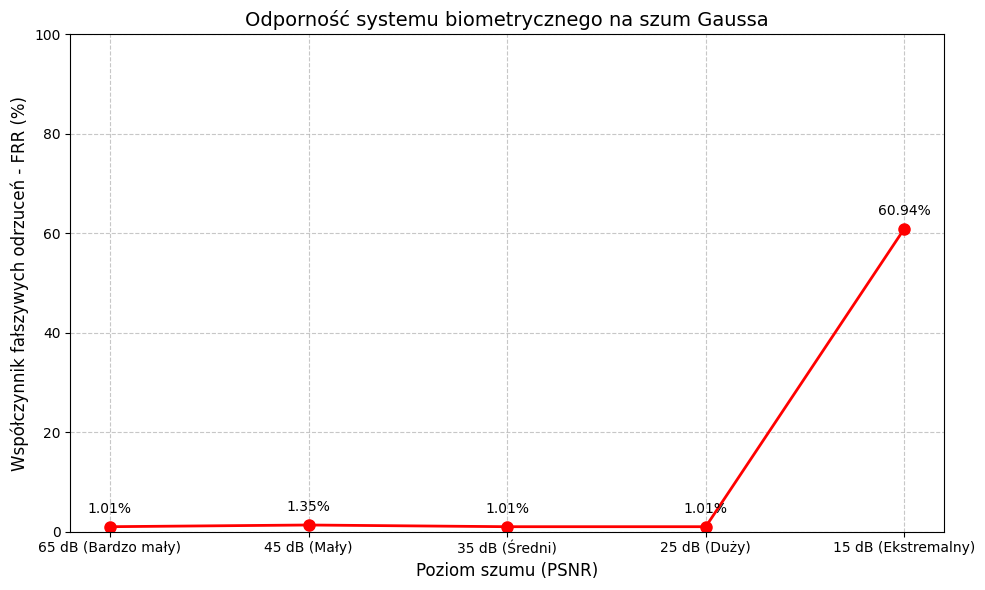

In [ ]:
import matplotlib.pyplot as plt

psnr_levels = ['65 dB', '45 dB', '35 dB', '25 dB', '15 dB']
frr_values = [1.01, 1.35, 1.01, 1.01, 60.94]

plt.figure(figsize=(10, 6))
plt.plot(psnr_levels, frr_values, marker='o', color='red', linewidth=2, markersize=8)

plt.title('Odporność systemu biometrycznego na szum Gaussa', fontsize=14)
plt.xlabel('Poziom szumu (PSNR)', fontsize=12)
plt.ylabel('Współczynnik fałszywych odrzuceń - FRR (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.ylim(0, 100)


for i, txt in enumerate(frr_values):
    plt.annotate(f"{txt}%", (i, frr_values[i]), textcoords="offset points", xytext=(0,10), ha='center')

plt.tight_layout()
plt.savefig('wykres_szum_psnr1.png')
plt.show()

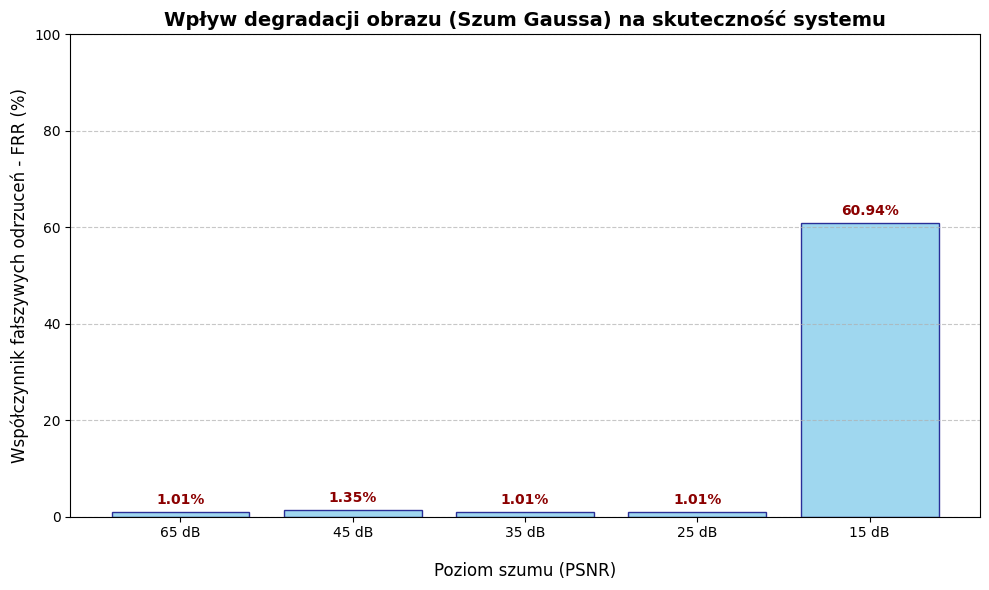

In [37]:
import matplotlib.pyplot as plt

psnr_levels = ['65 dB', '45 dB', '35 dB', '25 dB', '15 dB']

technical_labels = [
    '65 dB\n', 
    '45 dB\n', 
    '35 dB\n', 
    '25 dB\n', 
    '15 dB\n'
]
frr_values = [1.01, 1.35, 1.01, 1.01, 60.94]

plt.figure(figsize=(10, 6))

bars = plt.bar(technical_labels, frr_values, color='skyblue', edgecolor='navy', alpha=0.8)

plt.title('Wpływ degradacji obrazu (Szum Gaussa) na skuteczność systemu', fontsize=14, fontweight='bold')
plt.xlabel('Poziom szumu (PSNR)', fontsize=12)
plt.ylabel('Współczynnik fałszywych odrzuceń - FRR (%)', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0, 100) 

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval}%', ha='center', va='bottom', fontweight='bold', color='darkred')

plt.tight_layout()
plt.savefig('wykres_szum_psnr_v2.png')
plt.show()

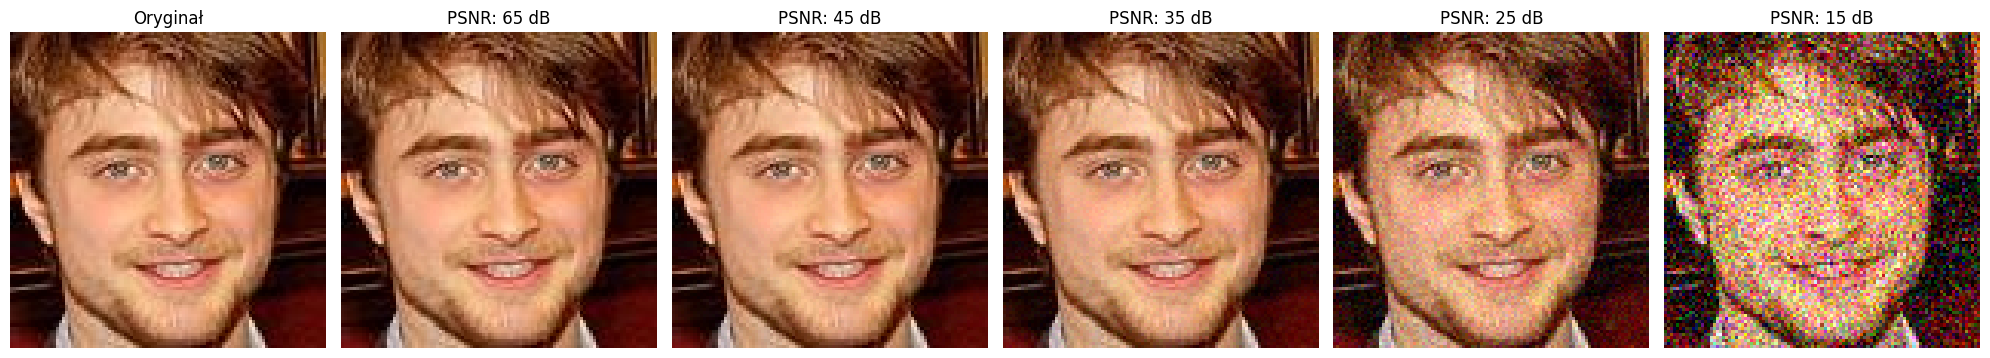

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def add_gaussian_noise(image, target_psnr):
    mse = (255.0 ** 2) / (10.0 ** (target_psnr / 10.0))
    sigma = np.sqrt(mse)
    noise = np.random.normal(0, sigma, image.shape)
    noisy_image = image.astype(np.float32) + noise
    return np.clip(noisy_image, 0, 255).astype(np.uint8)

img_path = 'data_processed/test_known\\Daniel_Radcliffe_Daniel_Radcliffe_27485_14764.jpeg'
img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

levels = [65, 45, 35, 25, 15]
titles = ['Oryginał (Czyste)', '45 dB (Lekki szum)', '35 dB', '25 dB (Wyraźny szum)', '15 dB (Ekstremalny)']

plt.figure(figsize=(20, 5))

plt.subplot(1, len(levels) + 1, 1)
plt.imshow(img_rgb)
plt.title("Oryginał")
plt.axis('off')

for i, psnr in enumerate(levels):
    noisy = add_gaussian_noise(img_rgb, psnr)
    plt.subplot(1, len(levels) + 1, i + 2)
    plt.imshow(noisy)
    plt.title(f"PSNR: {psnr} dB")
    plt.axis('off')

plt.tight_layout()
plt.show()

## 4. Badanie odporności na zmiany oświetlenia (Luminancja)
Eksperyment sprawdzający, czy algorytm jest niezmienny względem jasności obrazu. Modyfikujemy kanał Y w przestrzeni YCrCb (symulacja rzeczywistych warunków świetlnych).

In [ ]:
import cv2
import numpy as np

def modify_luminance_strictly(image, mode, value=None):
    ycrcb = cv2.cvtColor(image, cv2.COLOR_BGR2YCrCb)
    y, cr, cb = cv2.split(ycrcb)

    y_float = y.astype(np.float32)
    
    if mode == 'multiply':
        y_modified = y_float * value
    elif mode == 'add':
        y_modified = y_float + value
    elif mode == 'quadratic':
        y_norm = y_float / 255.0
        y_modified = (y_norm ** 2) * 255.0
        
    else:
        raise ValueError("Nieznany tryb modyfikacji!!!")

    y_modified = np.clip(y_modified, 0, 255).astype(np.uint8)
    
    result_image = cv2.cvtColor(cv2.merge([y_modified, cr, cb]), cv2.COLOR_YCrCb2BGR)
    return result_image

In [ ]:
import os
import random
from tqdm import tqdm

def test_all_luminance_experiments(test_folder, db, num_samples=300):
    all_files = [f for f in os.listdir(test_folder) if f.endswith(('.jpg', '.jpeg', '.png'))]
    all_db_ids = list(db.keys())
    
    random.seed(42) 
    selected_files = random.sample(all_files, num_samples)
    
    experiments = {
        "Mnożenie (1/2)": {'mode': 'multiply', 'val': 0.5},
        "Mnożenie (3/5)": {'mode': 'multiply', 'val': 0.6},
        "Mnożenie (3/4)": {'mode': 'multiply', 'val': 0.75},
        "Mnożenie (4/3)": {'mode': 'multiply', 'val': 1.333},
        "Mnożenie (3/2)": {'mode': 'multiply', 'val': 1.5},
        
        "Stała (-100)": {'mode': 'add', 'val': -100},
        "Stała (-20)":  {'mode': 'add', 'val': -20},
        "Stała (-10)":  {'mode': 'add', 'val': -10},
        "Stała (+30)":  {'mode': 'add', 'val': 30},
        
        "Skalowanie kwadratowe": {'mode': 'quadratic', 'val': None}
    }
    
    results = {}
    
    print(f"Rozpoczynam testy luminancji dla {num_samples} zdjęć...\n")
    
    for exp_name, params in experiments.items():
        genuine_scores = []
        
        for file_name in tqdm(selected_files, desc=f"Test: {exp_name:22}"):
            db_key_genuine = None
            for key in all_db_ids:
                base_name = key.replace('_ref', '') 
                if file_name.startswith(base_name):
                    db_key_genuine = key
                    break
                    
            if db_key_genuine is None:
                continue
                
            img_path = os.path.join(test_folder, file_name)
            img = cv2.imread(img_path)
            
            mod_img = modify_luminance_strictly(img, mode=params['mode'], value=params['val'])
            
            test_emb = get_embedding_from_image(mod_img)
            
            if test_emb is None:
                genuine_scores.append(0.0)
                print(f"Undetected face in modified image: {file_name} (Experiment: {exp_name})")
                continue
                
            sim_score = np.dot(test_emb, db[db_key_genuine])
            genuine_scores.append(sim_score)
            
        false_rejects = sum(1 for score in genuine_scores if score < OPTIMAL_THRESHOLD)
        frr = false_rejects / len(genuine_scores) if genuine_scores else 0
        results[exp_name] = frr
    
    print("\n" + "="*40)
    print("WYNIKI ODPORNOŚCI NA ZMIANY LUMINANCJI")
    print("="*40)
    for name, frr in results.items():
        print(f"{name:25} -> FRR: {frr*100:05.2f}%")

    return results

lum_results = test_all_luminance_experiments('data_processed/test_known', db, num_samples=300)

Rozpoczynam testy luminancji dla 300 zdjęć...



Test: Mnożenie (1/2)        :   0%|          | 0/300 [00:00<?, ?it/s]f:\Studia_pwr\semestr3\biometria\projekt1\projekt_biometria\facial-recognition-system\.venv\Lib\site-packages\insightface\utils\face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)
Test: Mnożenie (3/2)        :  92%|█████████▏| 276/300 [03:39<00:15,  1.56it/s]

Undetected face in modified image: Robert_Knepper_Robert_Knepper_96141_49846.jpeg (Experiment: Mnożenie (3/2))


Test: Stała (-100)          :  51%|█████▏    | 154/300 [02:10<01:53,  1.29it/s]

Undetected face in modified image: Jim_Beaver_Jim_Beaver_57838_30905.jpeg (Experiment: Stała (-100))


...

Undetected face in modified image: Danny_Trejo_Danny_Trejo_28633_15312.jpeg (Experiment: Stała (-100))


Test: Stała (-100)          :  96%|█████████▋| 289/300 [03:51<00:06,  1.71it/s]

Undetected face in modified image: Ken_Watanabe_Ken_Watanabe_69253_37069.jpeg (Experiment: Stała (-100))


Test: Skalowanie kwadratowe : 100%|██████████| 300/300 [03:31<00:00,  1.42it/s]


WYNIKI ODPORNOŚCI NA ZMIANY LUMINANCJI
Mnożenie (1/2)            -> FRR: 01.35%
Mnożenie (3/5)            -> FRR: 01.01%
Mnożenie (3/4)            -> FRR: 01.01%
Mnożenie (4/3)            -> FRR: 01.35%
Mnożenie (3/2)            -> FRR: 01.68%
Stała (-100)              -> FRR: 02.36%
Stała (-20)               -> FRR: 01.01%
Stała (-10)               -> FRR: 01.01%
Stała (+30)               -> FRR: 01.01%
Skalowanie kwadratowe     -> FRR: 01.01%


### Wizualizacja
Generujemy wykresy słupkowe, które podsumowują zachowanie systemu przy różnych modyfikacjach luminancji.

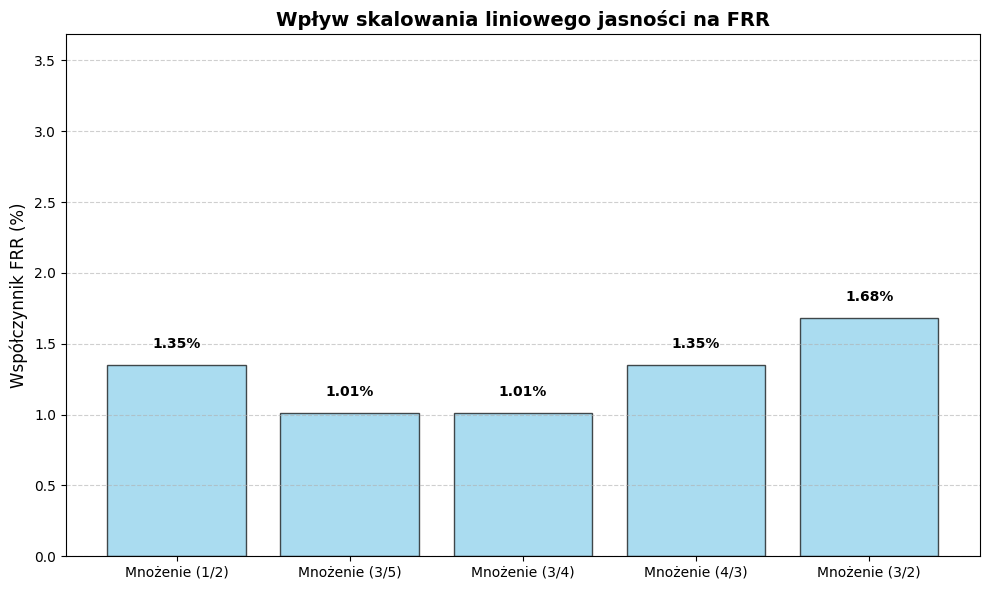

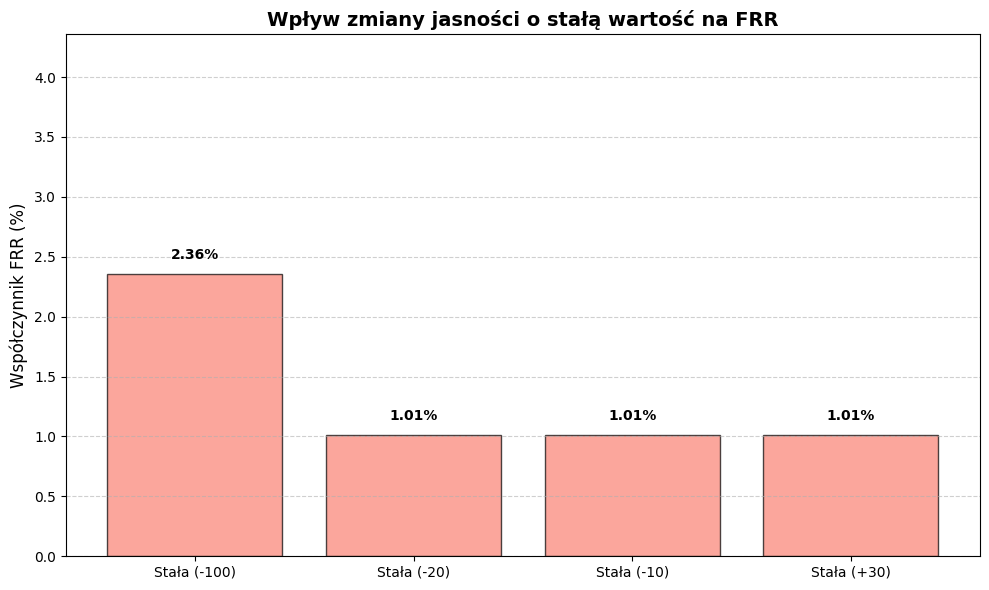

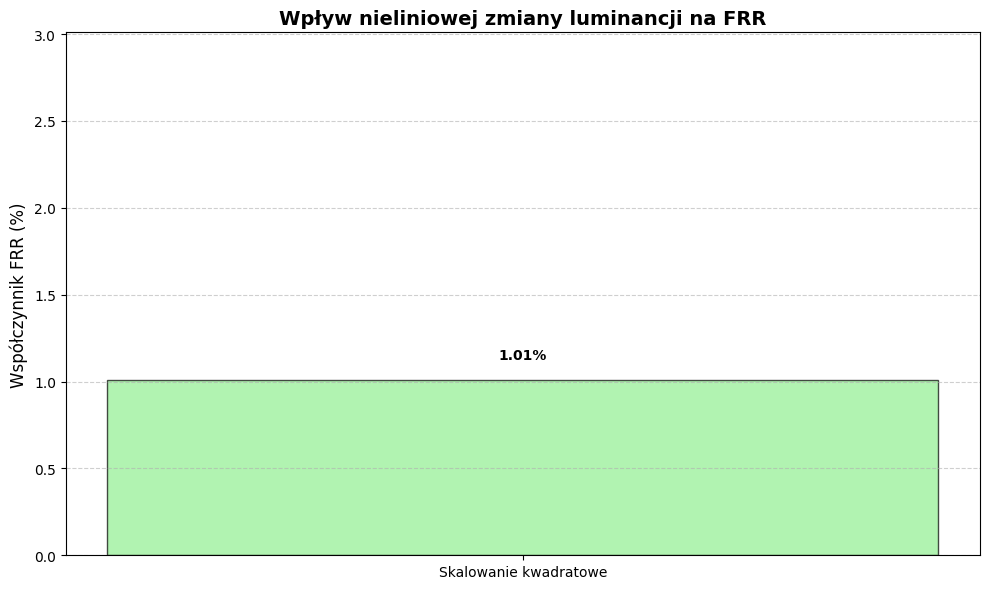

In [ ]:
import matplotlib.pyplot as plt
names = list(lum_results.keys())
values = [lum_results[name] * 100 for name in names] # Konwersja na procenty
multiplication = {k: v for k, v in lum_results.items() if "Mnożenie" in k}
addition = {k: v for k, v in lum_results.items() if "Stała" in k}
quadratic = {k: v for k, v in lum_results.items() if "kwadratowe" in k}

def draw_bar_chart(data_dict, title, filename, color):
    labels = list(data_dict.keys())
    values = [data_dict[label] * 100 for label in labels]
    
    plt.figure(figsize=(10, 6))
    bars = plt.bar(labels, values, color=color, alpha=0.7, edgecolor='black')
    
    plt.title(title, fontsize=14, fontweight='bold')
    plt.ylabel('Współczynnik FRR (%)', fontsize=12)
    plt.ylim(0, max(values) + 2 if values else 10)
    plt.grid(axis='y', linestyle='--', alpha=0.6)

    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, f"{yval:.2f}%", ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    plt.savefig(filename)
    plt.show()



draw_bar_chart(multiplication, 'Wpływ skalowania liniowego jasności na FRR', 'wykres_lum_mnozenie.png', 'skyblue')
draw_bar_chart(addition, 'Wpływ zmiany jasności o stałą wartość na FRR', 'wykres_lum_stala.png', 'salmon')
draw_bar_chart(quadratic, 'Wpływ nieliniowej zmiany luminancji na FRR', 'wykres_lum_kwadrat.png', 'lightgreen')

### 5. Badanie czasów wdrażania i identyfikacji

In [93]:
import time
import numpy as np
import cv2
import matplotlib.pyplot as plt

def benchmark_system(test_image_path, database):
    img = cv2.imread(test_image_path)
    h, w = img.shape[:2]
    
    start_enroll = time.perf_counter()
    
    # Preprocessing
    pad_h, pad_w = int(h * 0.4), int(w * 0.4)
    img_padded = cv2.copyMakeBorder(img, pad_h, pad_h, pad_w, pad_w, cv2.BORDER_CONSTANT, value=[0,0,0])
    
    # Detekcja i Ekstrakcja
    faces = app.get(img_padded)
    if len(faces) > 0:
        _ = faces[0].normed_embedding
    
    end_enroll = time.perf_counter()
    time_enroll = end_enroll - start_enroll

    test_emb = faces[0].normed_embedding
    target_emb = list(database.values())[0]
    
    start_1to1 = time.perf_counter()
    _ = np.dot(test_emb, target_emb) # (Cosine Similarity)
    end_1to1 = time.perf_counter()
    time_1to1 = end_1to1 - start_1to1

    embeddings_matrix = np.array(list(database.values()))
    
    start_1toN = time.perf_counter()
    similarities = np.dot(embeddings_matrix, test_emb)
    _ = np.argmax(similarities) # Znalezienie najlepiej dopasowanego
    end_1toN = time.perf_counter()
    time_1toN = end_1toN - start_1toN

    return time_enroll, time_1to1, time_1toN

(np.float64(-0.5), np.float64(499.5), np.float64(785.5), np.float64(-0.5))

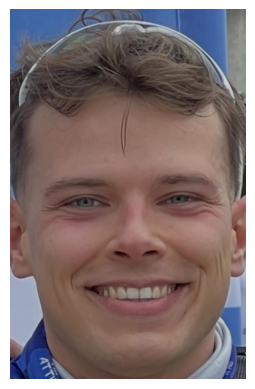

In [86]:
img = plt.imread('data_processed/test_known/Jakub_3.jpeg')
plt.imshow(img)
plt.axis('off')

In [95]:
with open("face_db.pkl", "rb") as f:
    loaded_db = pickle.load(f)

results = [benchmark_system("data_processed/test_known/Jakub_3.jpeg", loaded_db) for _ in range(100)]
avg_enroll = np.mean([r[0] for r in results])
avg_1to1 = np.mean([r[1] for r in results])
avg_1toN = np.mean([r[1] for r in results])

print(f"Średni czas wdrożenia: {avg_enroll:.4f} s")
print(f"Średni czas weryfikacji (1:1): {avg_1to1:.6f} s")
print(f"Średni czas identyfikacji (1:{len(loaded_db)}): {avg_1toN:.6f} s");

Średni czas wdrożenia: 0.0277 s
Średni czas weryfikacji (1:1): 0.000004 s
Średni czas identyfikacji (1:102): 0.000004 s


In [96]:
def check_identification(test_image_path, database, threshold=0.45):
    img = cv2.imread(test_image_path)
    h, w = img.shape[:2]
    pad_h, pad_w = int(h * 0.4), int(w * 0.4)
    img_padded = cv2.copyMakeBorder(img, pad_h, pad_h, pad_w, pad_w, cv2.BORDER_CONSTANT, value=[0,0,0])
    
    faces = app.get(img_padded)
    if not faces:
        return "Nie wykryto twarzy"
    
    test_emb = faces[0].normed_embedding

    names = list(database.keys())
    embeddings_matrix = np.array(list(database.values()), dtype=np.float32)

    similarities = np.dot(embeddings_matrix, test_emb)
    
    best_match_idx = np.argmax(similarities)
    best_score = similarities[best_match_idx]
    identified_name = names[best_match_idx]

    print(f"--- WYNIK IDENTYFIKACJI ---")
    print(f"Plik testowy: {test_image_path}")
    print(f"Rozpoznano jako: {identified_name}")
    print(f"Podobieństwo (Score): {best_score:.4f}")
    
    if best_score >= threshold:
        print("DOSTĘP PRZYZNANY")
    else:
        print("DOSTĘP ZABLOKOWANY (Poniżej progu)")
    
    return identified_name, best_score

In [97]:
check_identification("data_processed/test_known/Jakub_3.jpeg", loaded_db)

--- WYNIK IDENTYFIKACJI ---
Plik testowy: data_processed/test_known/Jakub_3.jpeg
Rozpoznano jako: Jakub_ref
Podobieństwo (Score): 0.6666
DOSTĘP PRZYZNANY


('Jakub_ref', np.float32(0.6666111))

### 7. Badanie wpływu kompresji JPEG na skuteczność systemu 

In [98]:
def test_jpeg_compression_impact(image_path, database, person_id, quality_levels=[95, 50, 10, 5]):
    img_orig = cv2.imread(image_path)
    if img_orig is None: return None
    
    h, w = img_orig.shape[:2]
    pad_h, pad_w = int(h * 0.4), int(w * 0.4)
    img_orig_padded = cv2.copyMakeBorder(img_orig, pad_h, pad_h, pad_w, pad_w, cv2.BORDER_CONSTANT, value=[0,0,0])
    
    if person_id not in database:
        print(f"{person_id} nie jest w bazie.")
        return None
    stored_embedding = database[person_id]

    results = []

    for quality in quality_levels:
        # params=[cv2.IMWRITE_JPEG_QUALITY, quality] ustawia poziom kompresji
        encode_param = [int(cv2.IMWRITE_JPEG_QUALITY), quality]
        success, encoded_img = cv2.imencode('.jpg', img_orig_padded, encode_param)
        
        if not success:
            continue
            
        img_compressed = cv2.imdecode(encoded_img, cv2.IMREAD_COLOR)

        faces = app.get(img_compressed)
        
        if len(faces) > 0:
            new_embedding = faces[0].normed_embedding
            similarity = np.dot(new_embedding, stored_embedding)
            results.append({'quality': quality, 'similarity': similarity, 'detected': True})
            print(f"JPEG Quality {quality:2d}: Similarity Score = {similarity:.4f}")
        else:
            results.append({'quality': quality, 'similarity': 0.0, 'detected': False})
            print(f"JPEG Quality {quality:2d}:Nie wykryto twarzy")

    return results

In [ ]:
def plot_jpeg_results(results, person_id):
    qualities = [r['quality'] for r in results if r['detected']]
    similarities = [r['similarity'] for r in results if r['detected']]
    
    plt.figure(figsize=(10, 6))
    plt.plot(qualities, similarities, marker='o', linestyle='-', color='b')
    plt.title(f"Wpływ kompresji JPEG na podobieństwo ({person_id})")
    plt.xlabel("Jakość JPEG (0-100)")
    plt.ylabel("Similarity Score (Cosine)")
    plt.grid(True)
    plt.axhline(y=0.45, color='r', linestyle='--', label='Próg decyzyjny (Threshold)')
    plt.legend()
    plt.show()

JPEG Quality 95: Similarity Score = 0.9982
JPEG Quality 50: Similarity Score = 0.9801
JPEG Quality 10: Similarity Score = 0.8598
JPEG Quality  5: Similarity Score = 0.6239


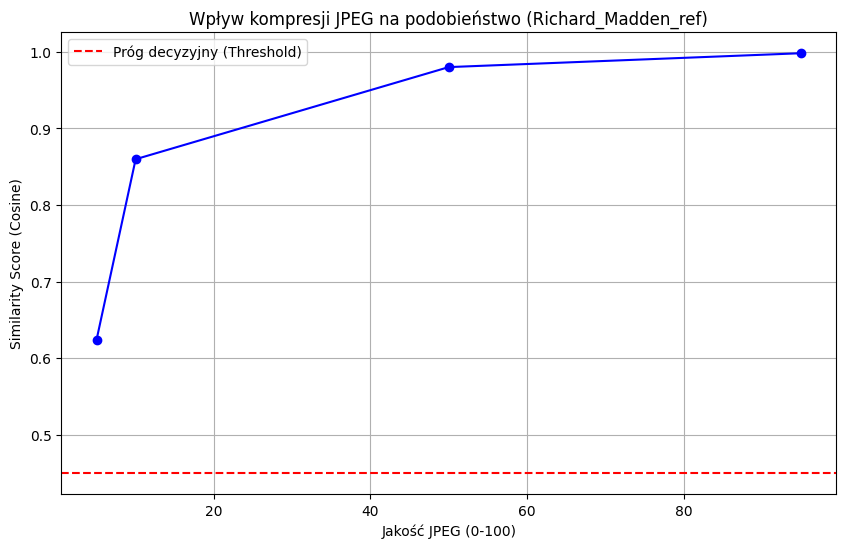

In [105]:
test_path = "data_processed/gallery/Richard_Madden_ref.jpg"
jpeg_results = test_jpeg_compression_impact(test_path, loaded_db, "Richard_Madden_ref")
plot_jpeg_results(jpeg_results, "Richard_Madden_ref");